# Análise Exploratória de Dados: Desempenho Acadêmico de Estudantes

**Disciplina:** Análise Exploratória de Dados (CCA_26_2)
**Grupo:** Arthur da Fonte, Matheus Freire, Matheus Fialho, Pablo Coelho, Rodrigo Vinhas, Bruno Holanda, Vitor Gadelha, Raul Maia

**Problema:** Identificar quais fatores estão mais associados ao desempenho e à aprovação dos alunos, para permitir intervenções antes da prova em vez de só constatar a reprovação depois.

**Fonte dos dados:** [Student Exam Performance & Success Dataset (Kaggle)](https://www.kaggle.com/datasets/mobeenfatimah/student-exam-performance-and-success-dataset)

**Perguntas de investigação:**
1. Quem estuda mais horas tira nota maior? (com retorno decrescente a partir de certo ponto?)
2. A frequência às aulas separa aprovados de reprovados?
3. Dormir pouco derruba o desempenho mesmo em quem estuda muito?

*(Preencher/ajustar conforme necessário — este é um template inicial.)*


## 1. Setup e Carregamento dos Dados

In [46]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Abra o notebook na raiz do repositório para acessar o módulo compartilhado.
RAIZ = Path.cwd() if (Path.cwd() / "analise").is_dir() else Path.cwd().parent
sys.path.insert(0, str(RAIZ / "analise"))
from exploracao import analisar, interpretar, gerar_graficos, exportar_tabelas
sns.set_style("whitegrid")


In [47]:
# Coloque o CSV na raiz do repositório ou altere este caminho.
CAMINHO_CSV = RAIZ / "student_exam_performance.csv"
df_completo = pd.read_csv(CAMINHO_CSV)
print("Shape original:", df_completo.shape)
df_completo.head()


Shape original: (100000, 44)


,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,...,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,...,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,...,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,...,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,...,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


O dataset original tem 44 colunas. Para esta análise, vamos manter apenas as 5 colunas
mais relevantes para as perguntas de investigação do grupo:

- `exam_score`: nota final da prova (variável de desempenho)
- `sleep_hours`: horas de sono
- `study_hours_per_day`: horas de estudo por dia
- `attendance_percentage`: percentual de frequência às aulas
- `pass_status`: status de aprovação (Pass / Fail)


In [48]:
colunas_selecionadas = [
    "exam_score",
    "sleep_hours",
    "study_hours_per_day",
    "attendance_percentage",
    "pass_status",
]

df = df_completo[colunas_selecionadas].copy()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   exam_score             100000 non-null  float64
 1   sleep_hours            100000 non-null  float64
 2   study_hours_per_day    100000 non-null  float64
 3   attendance_percentage  90137 non-null   float64
 4   pass_status            100000 non-null  str    
dtypes: float64(4), str(1)
memory usage: 3.8 MB


## 2. Pré-processamento de Dados

### 2.1 Valores nulos/ausentes

In [49]:
# Verificando quantos valores faltam em cada coluna
nulos = df.isnull().sum()
percentual_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "percentual (%)": percentual_nulos})


,nulos,percentual (%)
exam_score,0,0.00
sleep_hours,0,0.00
study_hours_per_day,0,0.00
attendance_percentage,9863,9.86
pass_status,0,0.00


**Tratamento adotado no script do grupo:** excluir registros com valores ausentes
nas cinco colunas selecionadas. O notebook usa agora o mesmo critério, para que
as métricas e os gráficos sejam comparáveis. A frequência tem 9.863 ausentes
no arquivo original. Essa exclusão pode introduzir viés se a ausência não for
aleatória; o tamanho da base não elimina esse risco. Não há imputação pela mediana.


In [50]:
n_original = len(df)
df = df.dropna().copy()
print("Registros excluídos por ausência:", n_original - len(df))
print("Registros completos:", len(df))


Registros excluídos por ausência: 9863
Registros completos: 90137


### 2.2 Dados duplicados

In [51]:
duplicadas = df.duplicated().sum()
print("Duplicatas nas cinco colunas selecionadas:", duplicadas)
# Mesmo critério do script. Coincidência nesses campos não prova identidade
# do estudante; caso haja duplicatas, a equipe deve conferir student_id.
df = df.drop_duplicates().copy()


Duplicatas nas cinco colunas selecionadas: 0


### 2.3 Conversão de tipos

`pass_status` vem como texto ("Pass"/"Fail"). Para poder usá-la em correlação e em métricas
estatísticas numéricas, criamos uma versão binária (`aprovado`: 1 = Pass, 0 = Fail), mantendo a
coluna original para leitura/gráficos.


In [52]:
df["aprovado"] = (df["pass_status"] == "Pass").astype(int)
df.dtypes


exam_score               float64
sleep_hours              float64
study_hours_per_day      float64
attendance_percentage    float64
pass_status                  str
aprovado                   int64
dtype: object

## 3. Análise Estatística

### 3.1 Medidas de Centralização (Média, Mediana, Moda)

In [53]:
variaveis_numericas = ["exam_score", "sleep_hours", "study_hours_per_day", "attendance_percentage"]

centralizacao = pd.DataFrame({
    "media": df[variaveis_numericas].mean(),
    "mediana": df[variaveis_numericas].median(),
    "moda": df[variaveis_numericas].mode().iloc[0],
})
centralizacao


,media,mediana,moda
exam_score,61.948243,61.95,100.00
sleep_hours,6.993977,7.00,7.17
study_hours_per_day,2.995330,2.67,0.50
attendance_percentage,84.616882,84.75,100.00


*(Comentar aqui o que os números indicam: ex. se média e mediana são próximas, distribuição tende a ser simétrica.)*

### 3.2 Medidas de Posição (Quartis)

In [54]:
quartis = df[variaveis_numericas].quantile([0.25, 0.5, 0.75])
quartis


,exam_score,sleep_hours,study_hours_per_day,attendance_percentage
0.25,51.23,6.18,1.72,79.21
0.50,61.95,7.00,2.67,84.75
0.75,72.74,7.81,3.91,90.17


### 3.3 Medidas de Dispersão (Variância, Desvio Padrão, Amplitude)

In [55]:
dispersao = pd.DataFrame({
    "variancia": df[variaveis_numericas].var(),
    "desvio_padrao": df[variaveis_numericas].std(),
    "amplitude": df[variaveis_numericas].max() - df[variaveis_numericas].min(),
})
dispersao


,variancia,desvio_padrao,amplitude
exam_score,252.093045,15.877438,100.00
sleep_hours,1.440648,1.200270,8.00
study_hours_per_day,2.948959,1.717253,11.50
attendance_percentage,62.765774,7.922485,53.66


### 3.4 Correlação de Pearson e Spearman

Pearson mede associação linear. Spearman utiliza postos e mede associação
monotônica, permitindo comparar os resultados sem exigir uma relação linear.
Os dois coeficientes variam de −1 a 1. O sinal indica a direção da associação;
o módulo indica sua intensidade segundo o método. Não estabelecem causalidade.

Usamos todas as linhas da base tratada. A aprovação não entra na matriz:
no arquivo, ela corresponde ao corte da própria nota em 50, e sua correlação
com a nota não acrescentaria um fator explicativo independente.


In [56]:
resultados_exploracao = analisar(df)
matriz_correlacao = resultados_exploracao["pearson"]
display(resultados_exploracao["associacoes"].round(4))
display(Markdown(interpretar(resultados_exploracao)))


,Pearson,Spearman,n
sleep_hours,0.1689,0.1617,90137
study_hours_per_day,0.3627,0.3407,90137
attendance_percentage,0.1691,0.1613,90137


Análise de 90,137 registros completos.

Sono (horas) e nota: Pearson = 0.169; Spearman = 0.162.

Estudo (horas/dia) e nota: Pearson = 0.363; Spearman = 0.341.

Frequência (%) e nota: Pearson = 0.169; Spearman = 0.161.

Entre os fatores selecionados, estudo (horas/dia) apresenta a maior associação linear em módulo com a nota nesta base.

Os coeficientes são associações bivariadas: não controlam outros fatores e não demonstram causalidade nem importância independente. Valores próximos de zero não descartam relações não lineares.

O Z-score permite comparar mediana, assimetria e extremos das distribuições de sono, estudo e frequência, apesar das unidades diferentes. Média zero e desvio padrão um são resultados da transformação, não descobertas sobre igualdade dos hábitos. Padronização não torna os dados normalmente distribuídos.

Pearson e Spearman não exigem Z-score e não mudam com essa transformação linear de escala positiva. O boxplot padronizado não mede efeito sobre a nota.

A exclusão de registros incompletos pode introduzir viés. As conclusões descrevem apenas a base utilizada; não estabelecem uma intervenção eficaz.

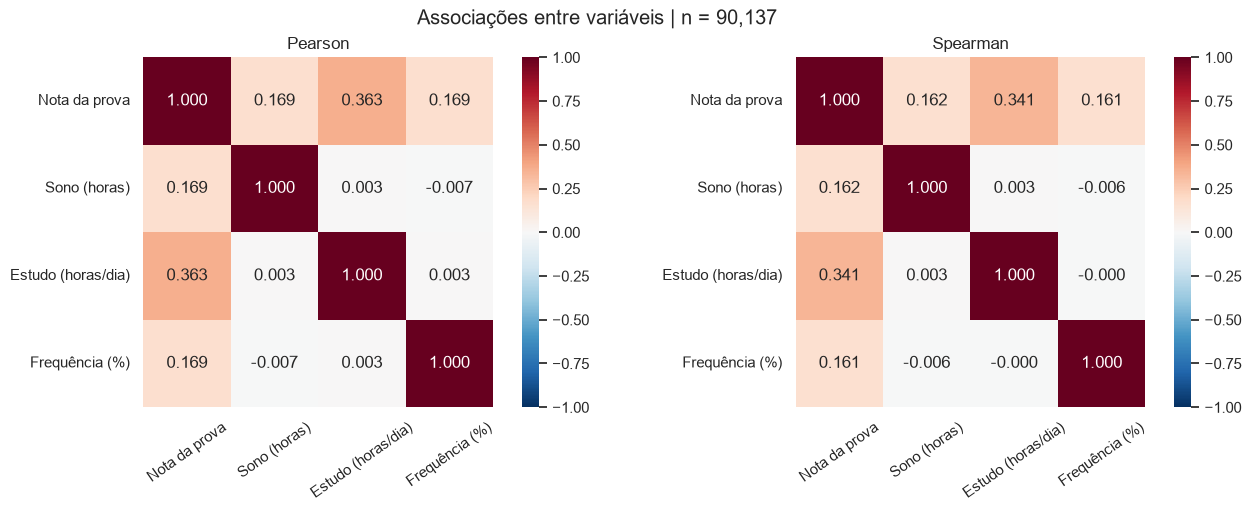

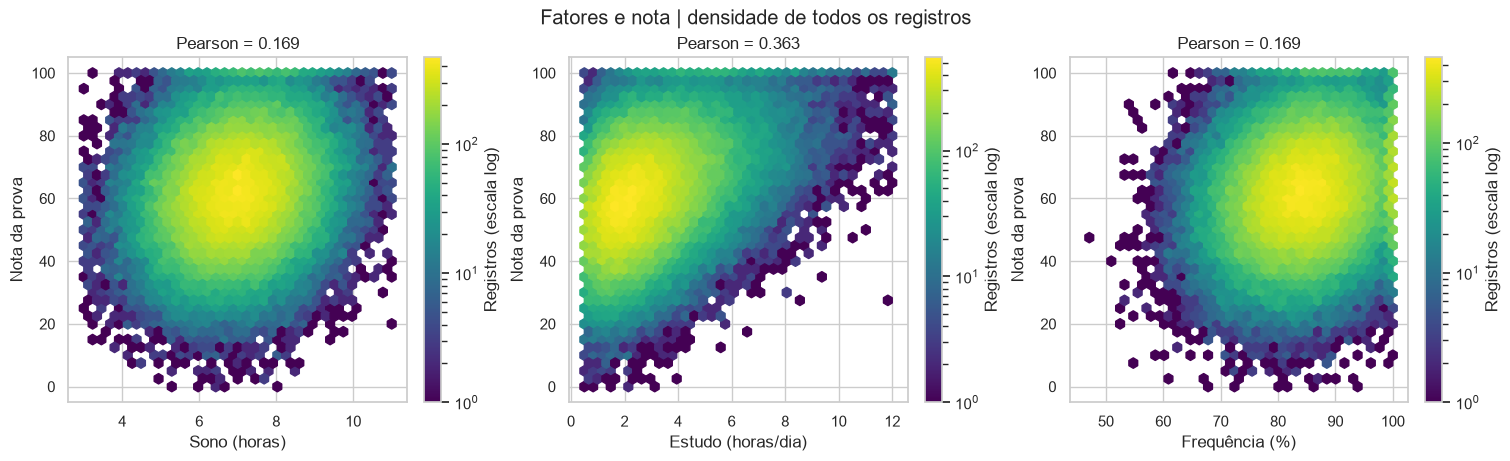

In [57]:
PASTA_RESULTADOS = RAIZ / "resultados"
figuras_exploracao = gerar_graficos(df, resultados_exploracao, PASTA_RESULTADOS)
# Fechar o registro do pyplot evita exibição duplicada automática.
for figura in figuras_exploracao.values():
    plt.close(figura)
display(figuras_exploracao["01_correlacoes"])
display(figuras_exploracao["02_fatores_e_nota"])


### 3.5 Padronização por Z-score


Sono e estudo estão em horas, enquanto frequência está em percentual.
Para comparar a posição relativa, a assimetria e os extremos de suas distribuições,
aplicamos **z = (x − média) / desvio padrão amostral**, com `ddof=1`.
A nota permanece como desfecho e os dados originais são preservados.

Após a transformação, cada fator tem média aproximadamente zero e desvio padrão
amostral um. Isso não torna as distribuições normais, não mede qual fator tem
maior efeito sobre a nota e não é necessário para Pearson ou Spearman.
A aplicação concreta da padronização neste projeto é o boxplot comparativo abaixo.


,media_z,desvio_padrao_z
sleep_hours,6.252732e-16,1.0
study_hours_per_day,1.623881e-16,1.0
attendance_percentage,3.846865e-17,1.0


,sleep_hours,study_hours_per_day,attendance_percentage
count,9.013700e+04,9.013700e+04,9.013700e+04
mean,6.252732e-16,1.623881e-16,3.846865e-17
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.327566e+00,-1.453094e+00,-4.831423e+00
25%,-6.781615e-01,-7.426570e-01,-6.824730e-01
50%,5.018268e-03,-1.894480e-01,1.680256e-02
75%,6.798665e-01,5.326353e-01,7.009313e-01
max,3.337602e+00,5.243647e+00,1.941704e+00


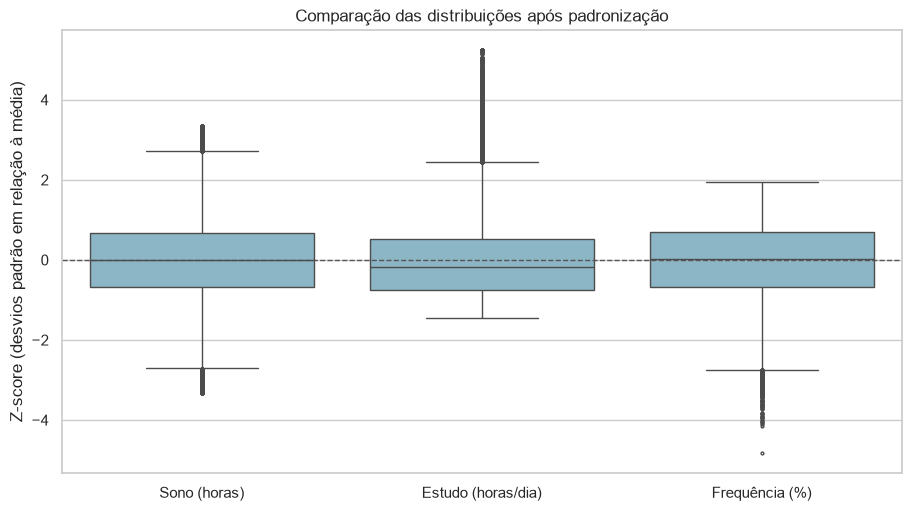

In [58]:
df_normalizado = resultados_exploracao["padronizados"]
display(resultados_exploracao["verificacao"])
display(df_normalizado.describe())
display(figuras_exploracao["04_padronizacao"])
exportar_tabelas(resultados_exploracao, PASTA_RESULTADOS)


## 4. Respondendo às Perguntas de Investigação

### Pergunta 1 — Quem estuda mais tira nota maior? Existe retorno decrescente?

In [59]:
df["faixa_estudo"] = pd.cut(
    df["study_hours_per_day"],
    bins=[0, 1, 2, 3, 4, df["study_hours_per_day"].max()],
    labels=["0-1h", "1-2h", "2-3h", "3-4h", "4h+"],
)

media_por_faixa_estudo = df.groupby("faixa_estudo", observed=True)["exam_score"].mean()
media_por_faixa_estudo


faixa_estudo
0-1h    53.738220
1-2h    56.942633
2-3h    60.407531
3-4h    63.753182
4h+     70.175278
Name: exam_score, dtype: float64

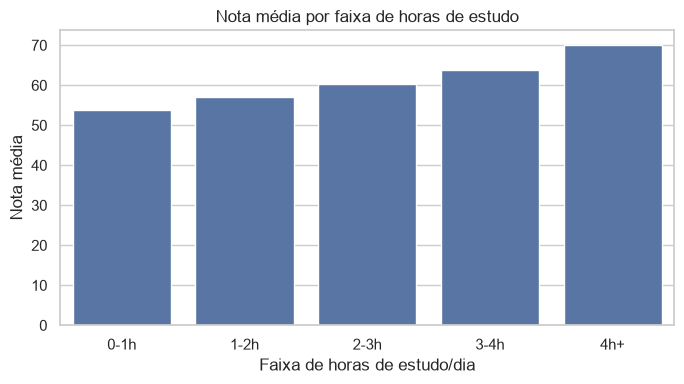

In [60]:
plt.figure(figsize=(7, 4))
sns.barplot(x=media_por_faixa_estudo.index, y=media_por_faixa_estudo.values)
plt.xlabel("Faixa de horas de estudo/dia")
plt.ylabel("Nota média")
plt.title("Nota média por faixa de horas de estudo")
plt.tight_layout()
plt.show()


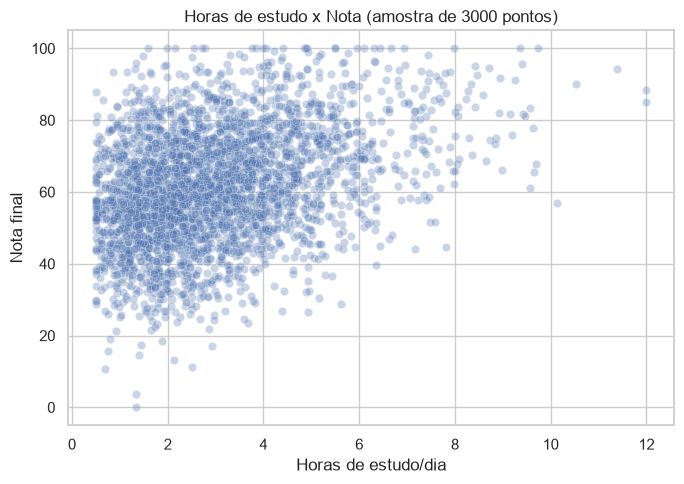

In [61]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df.sample(3000, random_state=42), x="study_hours_per_day", y="exam_score", alpha=0.3)
plt.xlabel("Horas de estudo/dia")
plt.ylabel("Nota final")
plt.title("Horas de estudo x Nota (amostra de 3000 pontos)")
plt.tight_layout()
plt.show()


### 4.1 Ganho de nota entre faixas de estudo

Para verificar se existe retorno decrescente, olhamos não só a nota média de cada
faixa, mas quanto ela sobe em relação à faixa anterior. Se esse ganho for
diminuindo conforme a faixa de estudo aumenta, é sinal de retorno decrescente.

In [62]:
# Quantos alunos tem em cada faixa, a nota média e quanto a nota sobe em relação à faixa anterior
contagem_faixa = df.groupby("faixa_estudo", observed=True)["exam_score"].count()
ganho_entre_faixas = media_por_faixa_estudo.diff()

pd.DataFrame({
    "n": contagem_faixa,
    "nota_media": media_por_faixa_estudo.round(2),
    "ganho_vs_faixa_anterior": ganho_entre_faixas.round(2),
})

,n,nota_media,ganho_vs_faixa_anterior
faixa_estudo,,,
0-1h,7350,53.74,NaN
1-2h,21836,56.94,3.20
2-3h,22847,60.41,3.46
3-4h,16916,63.75,3.35
4h+,21188,70.18,6.42


### 4.2 Pearson x Spearman (estudo e nota)

Pearson mede se a relação entre estudo e nota é linear. Spearman mede se a nota
sobe junto com o estudo, mesmo que essa subida não seja em linha reta. Se o
Spearman vier maior que o Pearson, é um indício de que a relação existe mas
não é reta — o que combina com a ideia de retorno decrescente.

In [63]:
from scipy import stats

# Pearson mede relação linear; Spearman mede se a nota sobe junto, mesmo que não seja em linha reta.
# Se o Spearman der maior que o Pearson, a relação sobe mas não é reta (combina com retorno decrescente).
r_pearson, p_pearson = stats.pearsonr(df["study_hours_per_day"], df["exam_score"])
r_spearman, p_spearman = stats.spearmanr(df["study_hours_per_day"], df["exam_score"])
print(f"Pearson: r = {r_pearson:.3f} (p = {p_pearson:.2e})")
print(f"Spearman: rho = {r_spearman:.3f} (p = {p_spearman:.2e})")

Pearson: r = 0.363 (p = 0.00e+00)
Spearman: rho = 0.341 (p = 0.00e+00)


### 4.3 Curva por decis de horas de estudo

Dividimos os alunos em 10 grupos do mesmo tamanho (decis) conforme as horas de
estudo, e calculamos a nota média de cada grupo. Com mais pontos do que as 5
faixas usadas acima, fica mais fácil ver se a curva "achata" nos decis mais altos.

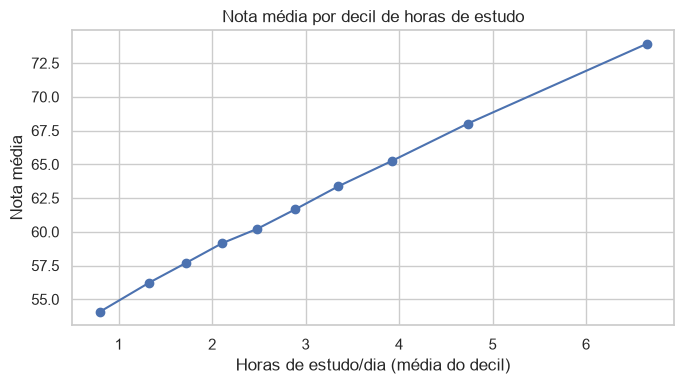

In [64]:
# Divide os alunos em 10 grupos do mesmo tamanho por horas de estudo e calcula a nota média de cada um
df["decil_estudo"] = pd.qcut(df["study_hours_per_day"], 10)
curva = df.groupby("decil_estudo", observed=True).agg(
    horas_media=("study_hours_per_day", "mean"),
    nota_media=("exam_score", "mean"),
)

plt.figure(figsize=(7, 4))
plt.plot(curva["horas_media"], curva["nota_media"], marker="o")
plt.xlabel("Horas de estudo/dia (média do decil)")
plt.ylabel("Nota média")
plt.title("Nota média por decil de horas de estudo")
plt.tight_layout()
plt.show()

**Conclusão da Hipótese 1:** a nota média sobe em todas as faixas de horas de
estudo, de 53,74 (0-1h, n=7.350) até 70,18 (4h+, n=21.188). Só que o ganho entre
faixas não diminui: fica em torno de 3,2 a 3,5 pontos nas primeiras faixas e sobe
para 6,42 pontos na última (4h+). A correlação de Pearson (r = 0,363) ficou
praticamente igual à de Spearman (rho = 0,341), sem indicar uma curva não-linear.

A curva por decil de horas de estudo reforça isso: os pontos ficam bem próximos
de uma reta, sem achatar nas faixas mais altas de estudo — pelo contrário, o
ganho parece um pouco maior no final.

**Hipótese 1: parcialmente confirmada.** A correlação positiva entre horas de
estudo e nota se confirma, mas a parte de retorno decrescente não aparece nos
dados: o ganho de nota não diminui conforme se estuda mais, e na faixa mais alta
ele até aumenta. É associação, não causa, e a base não tem contexto de escola,
país ou disciplina.

### Pergunta 2 — A frequência separa aprovados de reprovados?

In [65]:
comparacao_aprovacao = df.groupby("pass_status")[variaveis_numericas].mean()
comparacao_aprovacao


,exam_score,sleep_hours,study_hours_per_day,attendance_percentage
pass_status,,,,
Fail,40.753418,6.730847,2.284867,82.833591
Pass,68.143209,7.070886,3.202989,85.138114


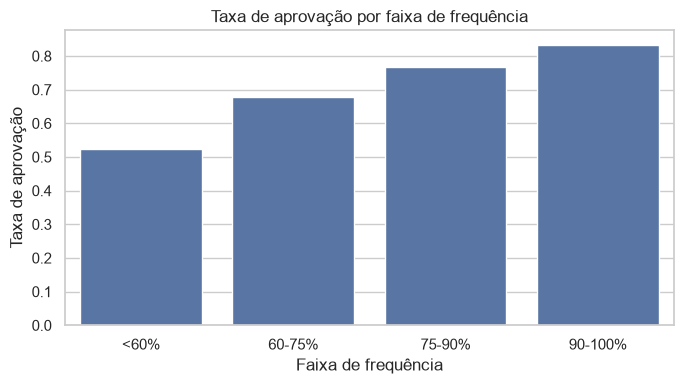

In [66]:
df["faixa_frequencia"] = pd.cut(
    df["attendance_percentage"],
    bins=[0, 60, 75, 90, 100],
    labels=["<60%", "60-75%", "75-90%", "90-100%"],
)

taxa_aprovacao_por_faixa = df.groupby("faixa_frequencia", observed=True)["aprovado"].mean()

plt.figure(figsize=(7, 4))
sns.barplot(x=taxa_aprovacao_por_faixa.index, y=taxa_aprovacao_por_faixa.values)
plt.xlabel("Faixa de frequência")
plt.ylabel("Taxa de aprovação")
plt.title("Taxa de aprovação por faixa de frequência")
plt.tight_layout()
plt.show()


In [67]:
from scipy import stats

pass_freq = df.loc[df["pass_status"] == "Pass", "attendance_percentage"]
fail_freq = df.loc[df["pass_status"] == "Fail", "attendance_percentage"]

print(f"Frequência média (Pass, n={len(pass_freq)}): {pass_freq.mean():.2f}% (desvio padrão {pass_freq.std():.2f})")
print(f"Frequência média (Fail, n={len(fail_freq)}): {fail_freq.mean():.2f}% (desvio padrão {fail_freq.std():.2f})")

# Teste t de Welch: a diferença de médias de frequência entre Pass e Fail é maior do que o acaso explicaria?
teste_frequencia = stats.ttest_ind(pass_freq, fail_freq, equal_var=False)
print(f"Welch t = {teste_frequencia.statistic:.2f}, p = {teste_frequencia.pvalue:.2e}")


Frequência média (Pass, n=69750): 85.14% (desvio padrão 7.83)
Frequência média (Fail, n=20387): 82.83% (desvio padrão 7.97)
Welch t = 36.46, p = 2.39e-285


**Conclusão da Hipótese 2:** quem passa tem frequência média de **85,1%** (n = 69.750), contra
**82,8%** de quem reprova (n = 20.387) — uma diferença de **2,3 pontos percentuais**. O teste t de
Welch (t ≈ 36,46; p ≈ 2,4e-285) indica que essa diferença não é fruto do acaso, dado o tamanho da base.

Ainda assim, a diferença é pequena diante da dispersão dentro de cada grupo (desvio padrão ≈ 7,9 a
8,0 pontos): as duas distribuições se sobrepõem bastante. A taxa de aprovação por faixa de frequência
(gráfico acima) mostra um gradiente — 52,3% (<60%, n=111), 67,7% (60-75%), 76,7% (75-90%) e 83,4%
(90-100%), mas mesmo na faixa mais alta de frequência ainda há reprovação relevante (16,6%).

**Hipótese 2: parcialmente confirmada.** A frequência está associada à aprovação e a diferença de
médias é estatisticamente significativa, mas o efeito é modesto: assim como no Pearson/Spearman da
seção 3.4 (r ≈ 0,17), a associação é real, porém fraca, e frequência sozinha não separa de forma
limpa aprovados de reprovados. É associação, não causa, e não controla os demais fatores (estudo, sono).


A comparação de médias por aprovação descreve os grupos, mas não estima
um efeito causal. A tabela da seção 3.4 compara associações bivariadas com a nota;
não representa o “peso” independente de cada fator.


### Pergunta 3 — Dormir pouco prejudica mesmo quem estuda muito?

In [68]:
from scipy import stats

# Isolando o grupo que mais estuda (top 25%)
limite_estudo = df["study_hours_per_day"].quantile(0.75)
grupo_estuda_muito = df[df["study_hours_per_day"] >= limite_estudo]

mediana_sono_grupo = grupo_estuda_muito["sleep_hours"].median()
dorme_pouco = grupo_estuda_muito[grupo_estuda_muito["sleep_hours"] < mediana_sono_grupo]
dorme_bem = grupo_estuda_muito[grupo_estuda_muito["sleep_hours"] >= mediana_sono_grupo]

print(f"Limite de estudo (percentil 75): {limite_estudo:.2f} h/dia | mediana de sono do grupo: {mediana_sono_grupo:.2f} h")
print(f"Nota média (estuda muito + dorme pouco, n={len(dorme_pouco)}):", round(dorme_pouco["exam_score"].mean(), 2))
print(f"Nota média (estuda muito + dorme bem,   n={len(dorme_bem)}):", round(dorme_bem["exam_score"].mean(), 2))
print("Taxa de aprovação (dorme pouco):", round(dorme_pouco["aprovado"].mean(), 3))
print("Taxa de aprovação (dorme bem):  ", round(dorme_bem["aprovado"].mean(), 3))

# Teste t de Welch: a diferença de médias é maior do que o acaso explicaria?
teste = stats.ttest_ind(dorme_pouco["exam_score"], dorme_bem["exam_score"], equal_var=False)
print(f"Welch t = {teste.statistic:.2f}, p = {teste.pvalue:.2e}")

# Comparação de controle: o mesmo corte por sono no quartil que menos estuda
grupo_estuda_pouco = df[df["study_hours_per_day"] <= df["study_hours_per_day"].quantile(0.25)]
mediana_sono_pouco = grupo_estuda_pouco["sleep_hours"].median()
nota_pouco_dorme_pouco = grupo_estuda_pouco.loc[grupo_estuda_pouco["sleep_hours"] < mediana_sono_pouco, "exam_score"].mean()
nota_pouco_dorme_bem = grupo_estuda_pouco.loc[grupo_estuda_pouco["sleep_hours"] >= mediana_sono_pouco, "exam_score"].mean()
print(f"Quem estuda pouco: dorme pouco = {nota_pouco_dorme_pouco:.2f} | dorme bem = {nota_pouco_dorme_bem:.2f}")

# Nota média do grupo que estuda muito, por faixa de horas de sono
faixa_sono = pd.cut(grupo_estuda_muito["sleep_hours"], bins=[0, 5, 6, 7, 8, 20],
                    labels=["<=5h", "5-6h", "6-7h", "7-8h", "8h+"])
nota_por_faixa_sono = grupo_estuda_muito.groupby(faixa_sono, observed=True)["exam_score"].agg(["mean", "count"])
nota_por_faixa_sono


Limite de estudo (percentil 75): 3.91 h/dia | mediana de sono do grupo: 7.00 h
Nota média (estuda muito + dorme pouco, n=11226): 67.78
Nota média (estuda muito + dorme bem,   n=11339): 72.04
Taxa de aprovação (dorme pouco): 0.878
Taxa de aprovação (dorme bem):   0.927
Welch t = -21.31, p = 9.68e-100
Quem estuda pouco: dorme pouco = 53.56 | dorme bem = 57.60


,mean,count
sleep_hours,,
<=5h,64.843760,1093
5-6h,66.788913,3534
6-7h,68.840147,6675
7-8h,70.956478,6771
8h+,73.661618,4492


**Conclusão da Hipótese 3:** no quartil que mais estuda (≥ 3,91 h/dia; 22.565 alunos), quem dorme menos que a
mediana do grupo (7 h) tem nota média de **67,8**, contra **72,0** de quem dorme 7 h ou mais — cerca de
**4,3 pontos** a menos. A taxa de aprovação também cai (87,8% contra 92,7%). O teste t de Welch
(p ≈ 1e-99) indica que essa diferença não é fruto do acaso. Além disso, a nota sobe de forma
gradual com o sono dentro do próprio grupo: 64,8 (≤5 h), 66,8, 68,8, 71,0 e 73,7 (8 h+).

O mesmo padrão aparece em quem estuda pouco (53,6 contra 57,6): o sono se associa a cerca de 4 pontos
de nota nos dois extremos de estudo. Estudar muito eleva o patamar, mas **não anula** a associação do
sono com a nota.

**Hipótese 3: confirmada.** Ressalva: é associação, não causa. A divisão por mediana é uma comparação
simples de médias, sem controle de outros fatores (regressão múltipla), e mais sono pode acompanhar
características do aluno que não estão nas cinco colunas analisadas.


## 5. Visualizações gerais

Os histogramas apresentam a concentração e a dispersão das variáveis, com linhas
para média e mediana. A densidade hexagonal da seção 3.4 inclui todos os registros,
e a cor representa a quantidade de observações em escala logarítmica. Os mapas de
calor usam a mesma escala de −1 a 1 para permitir comparação entre métodos.
O boxplot da seção 3.5 compara os fatores em unidades de desvio padrão; pontos
além dos bigodes não são automaticamente erros a remover.


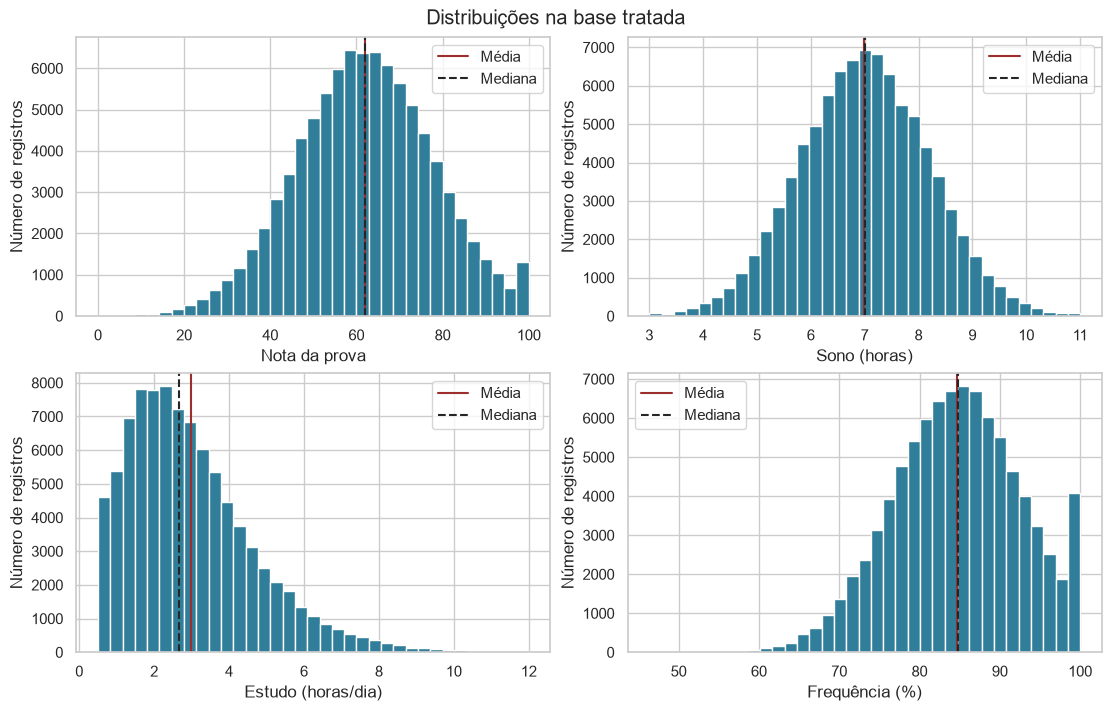

In [69]:
display(figuras_exploracao["03_distribuicoes"])


### Leitura dos gráficos da exploração

Na base tratada de 90.137 registros, a média da nota é 61,95 e a mediana é 61,95 (arredondadas). As horas de estudo apresentam cauda à direita: a média de 3,00 horas/dia supera a mediana de 2,67. O boxplot padronizado também mostra extremos superiores mais distantes para estudo.

Sono concentra-se em torno de 7 horas e frequência em torno de 85%. Há concentração de frequência no limite de 100%, visível no histograma. Proximidade entre média e mediana, isoladamente, não comprova simetria ou normalidade.

Os gráficos de densidade mostram ampla variação das notas para valores semelhantes dos fatores. Pearson e Spearman têm sinal positivo nos três casos; estudo apresenta a maior associação bivariada com a nota. Isso não comprova retorno decrescente, efeito independente da frequência ou efeito do sono entre quem estuda mais: essas são análises específicas das hipóteses.


## 6. Conclusões

*(Cada integrante deve revisar e escrever a conclusão final com as próprias palavras, retomando
as 3 hipóteses da planilha e dizendo se foram confirmadas, parcialmente confirmadas ou refutadas
com base nos números calculados acima.)*

- **Hipótese 1:**
- **Hipótese 2 (frequência separa aprovados de reprovados): parcialmente confirmada.** Quem passa tem frequência média 2,3 pontos percentuais maior que quem reprova (85,1% x 82,8%; Welch t ≈ 36,46, p ≈ 2,4e-285), e a taxa de aprovação cresce por faixa de frequência (52,3% → 67,7% → 76,7% → 83,4%). Mas a diferença é pequena frente ao desvio padrão de cada grupo (~7,9 pontos) e a correlação com a nota é fraca (r ≈ 0,17); frequência sozinha não separa de forma limpa aprovados de reprovados. É associação, não causa.
- **Hipótese 3 (sono importa mesmo para quem estuda muito): confirmada.** No quartil que mais estuda, quem dorme menos de 7 h tira em média 67,8 contra 72,0 de quem dorme 7 h ou mais (~4,3 pontos; Welch p ≈ 1e-99), e a nota sobe gradualmente com o sono. Estudar muito não anula essa associação; é associação, não causa.

### Limitações
Dataset genérico, sem contexto de país/escola/disciplina — mostra associação, não causa.